# PART3_Model_comparison
Compare genomic prediction model using GBLUP/Lasso/Enet/LGBM/RF

In [1]:
import ast
import time
import gzip
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
sns.set()

%matplotlib inline
%config InlineBackend.figure_formats = {'png', 'retina'}

from modules.make_data_for_prediction import make_data, make_data_for_Tuning
from modules.tuning import tuning_LightGBM, tuning_Lasso, tuning_ElasticNet, tuning_RandomForest
from modules.training import train_GBLUP, GBLUP_coef, train_lightgbm, train_randomforest, train_Lasso, train_Enet

# basic variables
family_list = pd.read_csv("../data/family_list.csv")
family = family_list.family.unique()
genotype = "../data/PART1_make_Haplotype_block/Haplotype_all_LD90.csv"
phenotype = "../data/phenotype_data/mean_phenotypes.csv"
traits = ["LW_mean", "GN_mean", "LL_mean", "DTH_mean", "PN_mean", "Area.size.AS..mm2."]
models = ["Lasso", "Enet", "LGBM", "RF"]
CV=5
optuna_seed=1024

# Training models using all RILs

## Parameter tuning for Lasso, Enet, LGBM, RF
Hyperparameter tuning by Optuna using training dataset only

In [ ]:
# tuning function
def tuning_model(X, y, model):
    if model == "Lasso":
        tuning_Lasso(X, y)
    elif model == "Enet":
        tuning_ElasticNet(X, y)
    elif model == "LGBM":
        tuning_LightGBM(X, y)
    elif model == "RF":
        tuning_RandomForest(X, y)

# parameter tuning for each model
for model in models:
    params = []
    for trait_name in traits:
        test_data, train_data, position_data = make_data(family, family_list, trait_name, genotype, phenotype, CV, seed=1024)
        for i in range(CV):
            train_data_CVn = train_data[i]
            X = train_data_CVn[0]; y = train_data_CVn[1]
            params.append([trait_name, i, tuning_model(X, y, model)])
    pd.DataFrame(params).to_csv(f"../data/PART3_Model_comparison/{model}_all_{trait_name}_params.csv")

## Train models
Train model using training dataset -> predict test dataset & check accuracy

In [ ]:
# get parameter function
def get_params(trait_name, i, model):
    params = pd.read_csv(f"../data/PART3_Model_comparison/{model}_all_{trait_name}_params.csv", index_col=0)
    params.columns = ["trait", "CV", "params"]
    params = ast.literal_eval(params.loc[(params["trait"] == trait_name) & (params["CV"] == i), "params"].values[0])
    return params

for trait_name in [trait_names[0]]:
    print(trait_name)
    # separate test & train dataset
    test_data, train_data, position_data = make_data(family, family_list, trait_name, genotype, phenotype, CV, seed=1024, plot=False)

    summary = []
    for i in range(CV):
        print("CV{}".format(i))
        start = time.time()
        tmp_test_data = test_data[i]
        tmp_train_data = train_data[i]
        
        # train all models
        for model in models:
            print(f"{model} start")
            if model == "GBLUP":
                test_pred, h2, r2, acc_RIL = train_GBLUP(tmp_test_data, tmp_train_data, genotype)
                coefs = GBLUP_coef(tmp_train_data, genotype)
            elif model == "LGBM":
                test_preds, r2, acc_RIL, coefs = train_lightgbm(tmp_test_data, tmp_train_data, get_params(trait_name, i, model))
            elif model == "RF":
                test_pred, r2, acc_RIL, coefs = train_randomforest(tmp_test_data, tmp_train_data, get_params(trait_name, i, model))
            elif model == "Lasso":
                test_pred, r2, acc_RIL, coefs = train_Lasso(tmp_test_data, tmp_train_data, get_params(trait_name, i, model))
            elif model == "Enet":
                test_pred, r2, acc_RIL, coefs = train_Enet(tmp_test_data, tmp_train_data, get_params(trait_name, i, model))
            
            summary.append([trait_name, i, "GBLUP", test_pred, r2, acc_RIL, coefs])
    
    with gzip.open('../data/PART3_Model_comparison/Compare_models_DCV_by_all_RILs_HBs_{}.pic.bin.gz'.format(trait_name), 'wb') as p:
        pickle.dump(summary, p)  

## check accuracy of all models for each trait & RILs

In [2]:
model_order = {'GBLUP': 0, 'Lasso': 1, 'Enet': 2, 'LGBM': 3, 'RF': 4}            
palette = sns.color_palette(['#56B4E9', '#009E73', '#E69F00', '#0072B2', '#F0E442'])

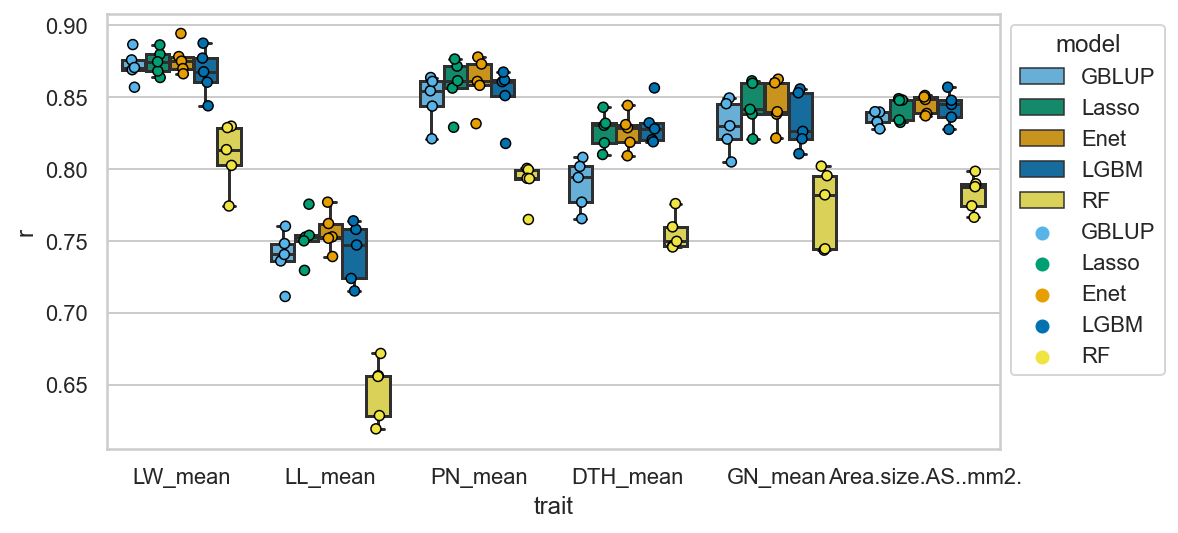

In [7]:
# make dataframe for boxplot
bar_data = []
for trait_name in traits:
    with gzip.open('../data/PART3_Model_comparison/Compare_models_DCV_by_all_RILs_HBs_{}.pic.bin.gz'.format(trait_name), 'rb') as p:
        summary = pickle.load(p)
    summary = pd.DataFrame(summary)
    for model in models:
        for CV in range(5):
            bar_data.append([trait_name, model, summary[(summary.iloc[:, 0] == trait_name) & (summary.iloc[:, 2] == model) & (summary.iloc[:, 1] == CV)].iloc[:, 4].values[0]])

bar_data = pd.DataFrame(bar_data)
bar_data.columns = ["trait", "model", "r"]
bar_data = bar_data.sort_values('model', key=lambda col: col.map(model_order))

# visualize boxplot
sns.set(style='whitegrid', color_codes=True)
plt.figure(figsize=(8,4))
ax = sns.boxplot(x="trait", y="r", hue="model", data=bar_data, sym="", palette=palette)
sns.stripplot(x="trait", y="r", hue="model", data=bar_data, dodge=True, edgecolor="black", linewidth=.75, ax=ax, palette=palette)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.show()